# Template matching notebook for tilt series and selected rois

This notebook can be run after preprocessing the data. Regions of interest (rois) are chosen from different crystals. The subsets are then template matched, in order to index the crystals from the different tilts.

## Contents
 1. [Load the data](#1.-Load-the-data)
 2. [Define/load rois](#2.-Define/load-rois)
 3. [Create subsets](#3.-Create-subsets)
 4. [Polar transform](#4.-Polar-transform)
 5. [Create a library of simulated diffraction patterns](#5.-Create-library-of-simulated-diffraction-patterns)
 6. [Load simulations](#7.-Load-simulations)
 7. [Template match](#7.-Template-match)
 8. [Save results](#8.-Save-results)
 9. [axis-angle-selected orientations](#9.-Create-crystal-maps)
 10. [IPF validation plots](#10.-Save-representative-pixels)
 11. [Save](#1.-Save)


goal
1. Finalize representative_pixels.json
2. Make one clean m-3m IPF plot for A–D
3. Make one stereographic plot with all arcs A–D
4. Make misorientation-vs-tilt plot
5. Save all figures
6. Write 5–8 sentences explaining limitations

In [1]:
%matplotlib widget

import json
import pickle
from pathlib import Path
import requests

import warnings
warnings.filterwarnings('ignore')

import hyperspy.api as hs
import pyxem as pxm
import numpy as np
import matplotlib.pyplot as plt #Plotting tools
import matplotlib.colors as mcolors #Some plotting color tools
from matplotlib.cm import ScalarMappable
import diffpy #Electron diffraction tools
from matplotlib.colors import to_rgb


#Import indexation and plotting tools
from diffsims.generators.rotation_list_generators import get_beam_directions_grid
from diffsims.libraries.structure_library import StructureLibrary
from diffsims.generators.diffraction_generator import DiffractionGenerator
from diffsims.generators.library_generator import DiffractionLibraryGenerator
from diffsims.generators.simulation_generator import SimulationGenerator

#Import orientation handling tools
from orix.quaternion import Rotation, symmetry, Orientation, OrientationRegion
from orix.crystal_map import Phase
from orix.vector.vector3d import Vector3d
from orix.vector import Miller
from orix.projections import StereographicProjection
from orix import plot
from orix.plot import IPFColorKeyTSL
from orix.sampling import get_sample_reduced_fundamental
from orix.io import save, load

from sklearn.decomposition import PCA
import itertools

In [2]:
#import functions from src
import sys
import importlib

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import src.roi_utils
import src.template_matching
importlib.reload(src.template_matching)
import src.axis_angle
importlib.reload(src.axis_angle)

from src.roi_utils import load_rois, save_rois_by_tilt, extract_roi_subsets
from src.template_matching import load_polar_rois, run_template_matching

from src.axis_angle import get_candidates_for_pixel, select_candidates_axis_angle, run_axis_angle_selection, smallest_symmetry_misorientation, run_axis_angle_selection_all_twins

In [3]:
import importlib
import src.axis_angle_denis as aad

importlib.reload(aad)

from src.axis_angle_denis import (
    run_denis_selection,
    run_denis_selection_all_twins,
    print_tilt_step_misorientation,
)

In [4]:
import importlib

import src.representative_pixel as rpa
importlib.reload(rpa)

from src.representative_pixel import (
    choose_representative_pixels_all_twins,
)

# 1. Load the data

In [5]:
# load data from 7 tilts
datasets = [
    {"tilt": +10, "path": Path("../../data/20260417_Ingrid/093932/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_18p2_Ty3p8_cropped_centered_masked.hspy")},
    {"tilt": +5,  "path": Path("../../data/20260417_Ingrid/100104/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_13p2_Ty3p8_cropped_centered_masked.hspy")},
    {"tilt": 0,   "path": Path("../../data/20260417_Ingrid/091336/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_8p2_Ty3p8_big_centered_masked.hspy")},
    {"tilt": -5,  "path": Path("../../data/20260417_Ingrid/101949/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_3p2_Ty3p8_cropped_centered_masked.hspy")},
    {"tilt": -10, "path": Path("../../data/20260417_Ingrid/103611/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_m2p2_Ty3p8_cropped_centered_masked.hspy")},
    {"tilt": -15, "path": Path("../../data/20260417_Ingrid/105201/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_m7p2_Ty3p8_cropped_centered_masked.hspy")},
    {"tilt": -20, "path": Path("../../data/20260417_Ingrid/110843/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_m12p2_Ty3p8_cropped_centered_masked.hspy")},
]
results_path = Path("../results")

In the next cell, the SPED datasets are loaded lazily using HyperSpy in order to reduce memory usage during preprocessing, in addition to be chunked and normalized.

Each diffraction pattern is normalized to its maximum intensity before template matching: I_norm = I/(I_max + e), where e = 10^(-8) avoids division by zero. This reduces intensity variations between diffraction patterns and imporves robustness of template matching across tilt series.



In [6]:
lazy = True

loaded = {}

for d in datasets:
    
    tilt = d["tilt"]
    datapath = d["path"]

    print(f"Loading tilt {tilt}")

    signal = hs.load(str(datapath), lazy=lazy)

    if lazy:
        signal.rechunk(
            nav_chunks=(32, 32),
            sig_chunks=(32, 32)
        )
    
    # normalize each diffraction pattern
    signal.map(lambda x: x / (x.max() + 1e-8), inplace=True)

    print(f"  Shape: {signal.data.shape}  dtype: {signal.data.dtype}")
    
    loaded[tilt] = signal

Loading tilt 10
  Shape: (109, 187, 256, 256)  dtype: float64
Loading tilt 5
  Shape: (164, 229, 256, 256)  dtype: float64
Loading tilt 0
  Shape: (153, 209, 256, 256)  dtype: float64
Loading tilt -5
  Shape: (151, 232, 256, 256)  dtype: float64
Loading tilt -10
  Shape: (194, 234, 256, 256)  dtype: float64
Loading tilt -15
  Shape: (124, 198, 256, 256)  dtype: float64
Loading tilt -20
  Shape: (163, 235, 256, 256)  dtype: float64


# 2. Define/load rois

In [7]:
signals = loaded

roi_path = results_path / "roi_by_tilt.json"

if roi_path.exists():
        
        print(f"Loading ROIs")
        roi_by_tilt = load_rois(roi_path)

else:
    
    print("No ROI file. Define interactively")

    roi_by_tilt = {}

    for tilt, signal in signals.items():

        print(f"\n Tilt {tilt}")
        

        roi_A = hs.roi.RectangularROI(left=100.58, right=177.99, top=603.77, bottom=635.18)
        roi_B = hs.roi.RectangularROI(left=247.79, right=279.20, top=572.36, bottom=603.77)
        roi_C = hs.roi.RectangularROI(left=474.64, right=506.05, top=607.26, bottom=638.67)
        roi_D = hs.roi.RectangularROI(left=628.20, right=659.61, top=771.29, bottom=602.70)

        signal.plot(norm="symlog")

        roi_A.add_widget(signal, color="red")
        roi_B.add_widget(signal, color="aqua")
        roi_C.add_widget(signal, color="mediumorchid")
        roi_D.add_widget(signal, color="hotpink")

        roi_by_tilt[tilt] = {
            "A": roi_A,
            "B": roi_B,
            "C": roi_C,
            "D": roi_D
        }

Loading ROIs


## Save and visualize new rois

In [ ]:
assert False

In [ ]:
# save current ROIs
save_rois_by_tilt(roi_by_tilt, roi_path)

In [ ]:
colors = {
    "A": "red",
    "B": "aqua",
    "C": "mediumorchid",
    "D": "hotpink"
}

for tilt, signal in signals.items():

    print(f"Tilt {tilt}")

    # plot dataset
    signal.plot(norm="symlog")

    rois = roi_by_tilt[tilt]

    # add overlays
    for key, roi in rois.items():
        roi.add_widget(signal, color=colors[key])

# 3. Create subsets

In [ ]:
roi_subsets = extract_roi_subsets(
    signals,
    roi_by_tilt
)

In [ ]:
#plot rois from one tilt to inspect
tilt = 0  # choose your reference tilt

for i, key in enumerate(["A", "B", "C", "D"]):

    subset = roi_subsets[tilt][key]

    subset.plot(norm="symlog", cmap="magma")

plt.tight_layout()

# 4. Polar transform

In [ ]:
roi_polar = {}

npt = 128
npt_azim=360

polar_root = results_path / "polar_rois"
polar_root.mkdir(parents=True, exist_ok=True)

for tilt, roi_dict in roi_subsets.items():

    print(f"\nProcessing tilt {tilt}")

    roi_polar[tilt] = {}

    tilt_dir = polar_root / f"tilt_{tilt}"
    tilt_dir.mkdir(parents=True, exist_ok=True)

    for key, subset in roi_dict.items():

        print(f"  ROI {key}")

        #prepare data

        subset = subset.copy()
        subset.change_dtype("float32")

        #convert form cartesian to polar coordinates
        subset_pol = subset.get_azimuthal_integral2d(
            npt=npt,
            npt_azim=npt_azim
        )

        # save polar data
        roi_polar[tilt][key] = subset_pol

        subset_pol.save(tilt_dir / f"ROI_{key}_polar.hspy")


    

# 5. Create library of simlulated diffraction patterns

create simulations

In [ ]:
fname = 'GaAs.cif'
url = "https://materials.springer.com/downloads/track-required/true?path=%2Fassets%2Fsm_isp%2Fcrystallographic%2F311%2Fsm_isp_sd_0311662%2Fsm_isp_sd_0311662_download.cif&componentId=Download+Data+CIF"
r = requests.get(url)
open(fname , 'wb').write(r.content)

GaAs = Phase.from_cif(fname)

In [ ]:
GaAs = Phase.from_cif("../../GaAs.cif")

angular_resolution = 0.5
grid = get_sample_reduced_fundamental(
    resolution=angular_resolution,
    point_group=GaAs.point_group
)

sim_gen = SimulationGenerator(
    accelerating_voltage=200,
    precession_angle=1,
    minimum_intensity=1e-10
)

simulations = sim_gen.calculate_diffraction2d(
    phase=GaAs,
    rotation=grid,
    reciprocal_radius=2,
    with_direct_beam=False
)

orientations = Orientation(
    grid,
    symmetry=GaAs.point_group
)

key_x = IPFColorKeyTSL(GaAs.point_group, Vector3d.xvector())
key_y = IPFColorKeyTSL(GaAs.point_group, Vector3d.yvector())
key_z = IPFColorKeyTSL(GaAs.point_group, Vector3d.zvector())

In [ ]:
simulation_root = results_path / "simulation_library"
simulation_root.mkdir(parents=True, exist_ok=True)

sim_path = simulation_root / "GaAs_simulations_angres0p5_r2_mi1em10.pkl"
grid_path = simulation_root / "GaAs_grid_angres0p5.pkl"

In [ ]:
simulation_root = results_path / "simulation_library"
simulation_root.mkdir(parents=True, exist_ok=True)

sim_path = simulation_root / "GaAs_simulations_angres0p5_rr2.pkl"
grid_path = simulation_root / "GaAs_grid_angres0p5.pkl"

with open(sim_path, "wb") as f:
    pickle.dump(simulations, f)

with open(grid_path, "wb") as f:
    pickle.dump(grid, f)

print("Simulation library saved.")

In [ ]:
#visualize orienations
orientations.scatter('ipf')
orientations

In [ ]:
simulations.plot(interactive=True)

# 5. Load saved simulation

In [8]:
simulation_root = results_path / "simulation_library"
simulation_root.mkdir(parents=True, exist_ok=True)

sim_path = simulation_root / "GaAs_simulations_angres0p5_r2_mi1em10.pkl"
grid_path = simulation_root / "GaAs_grid_angres0p5.pkl"

In [9]:
GaAs = Phase.from_cif("../../GaAs.cif")

with open(sim_path, "rb") as f:
    simulations = pickle.load(f)

with open(grid_path, "rb") as f:
    grid = pickle.load(f)

orientations = Orientation(
    grid,
    symmetry=GaAs.point_group,
)

key_x = IPFColorKeyTSL(GaAs.point_group, Vector3d.xvector())
key_y = IPFColorKeyTSL(GaAs.point_group, Vector3d.yvector())
key_z = IPFColorKeyTSL(GaAs.point_group, Vector3d.zvector())

print("Simulation library loaded.")

Simulation library loaded.


# 6. Template match

For each ROI and each tilt, the polar-transformed diffraction patterns are compared with the simulated diffraction library.

The best-matching simulated crystal orientaitons are returned for each scan pixel.

Workflow:
diffraction pattern -> polar transform -> simulation comparison -> best-matching orientation

## one

In [ ]:
tilt = -15
key = "C"

n_keep = 8
npt = 128
npt_azim = 360

subset = roi_subsets[tilt][key].copy()

subset.change_dtype("float32")

subset_pol = subset.get_azimuthal_integral2d(
    npt=npt,
    npt_azim=npt_azim
)

res = subset_pol.get_orientation(
    simulation=simulations,
    n_best=8,
    frac_keep=1.0
)

subset_pol.plot(norm="symlog")

subset_pol.add_marker(
    res.to_single_phase_polar_markers(
        signal_axes=subset_pol.axes_manager.signal_axes
    )
)

In [ ]:
subset = roi_subsets[-15]["C"]
subset.plot(cmap='viridis_r', norm='symlog')
subset.add_marker(res.to_markers(annotate=True))


In [ ]:
roi_results = {}
roi_results[tilt] = {}
res = subset_pol.get_orientation(
            simulation=simulations,
            n_best=n_keep,
            frac_keep=1.0
        )

        roi_results[tilt][key] = res

In [ ]:
assert False

### check one match

In [ ]:
pol_0_A = roi_polar[-15]["C"]


pol_0_A.plot()

pol_0_A.add_marker(roi_results[-15]["C"].to_single_phase_polar_markers(signal_axes=pol_0_A.axes_manager.signal_axes))


In [ ]:
res_0_A= pol_0_A.get_orientation(simulations, n_best=n_keep, frac_keep=1.0)
res_0_A



In [ ]:
res_0_A = roi_subsets[-15]["C"]

res_0_A.plot(cmap='viridis_r', norm='log')
res_0_A.add_marker(roi_results[-15]["C"].to_markers(annotate=True))


# Load polar-transformed ROIs

In [10]:
polar_root = results_path / "polar_rois"

roi_polar = load_polar_rois(polar_root)


Tilt -10
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt -15
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt -20
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt -5
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt 0
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt 10
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete

Tilt 5
Found 4 files
Loading ROI A
Loading ROI B
Loading ROI C
Loading ROI D
complete


## Compute (template match)

In [11]:
roi_results = run_template_matching(
    roi_polar,
    simulations,
    n_keep=8,
)

Tilt -20, ROI A
WARNING | Hyperspy | The function you applied does not take into account the difference of scales in-between axes. (hyperspy.signal:5597)
WARNING | Hyperspy | The function you applied does not take into account the difference of units in-between axes. (hyperspy.signal:5602)
TM complete
Tilt -20, ROI B
WARNING | Hyperspy | The function you applied does not take into account the difference of scales in-between axes. (hyperspy.signal:5597)
WARNING | Hyperspy | The function you applied does not take into account the difference of units in-between axes. (hyperspy.signal:5602)
TM complete
Tilt -20, ROI C
WARNING | Hyperspy | The function you applied does not take into account the difference of scales in-between axes. (hyperspy.signal:5597)
WARNING | Hyperspy | The function you applied does not take into account the difference of units in-between axes. (hyperspy.signal:5602)
TM complete
Tilt -20, ROI D
WARNING | Hyperspy | The function you applied does not take into account th

In [ ]:
# quick inspection
tilt = -
roi_key = "C"

pol = roi_polar[tilt][roi_key]
res = roi_results[tilt][roi_key]

pol.plot()
pol.add_marker(
    res.to_single_phase_polar_markers(
        signal_axes=pol.axes_manager.signal_axes
    )
)

## Manual candidate selection and quality control

For each ROI, a representative scan pixel was chosen based on the IPF-Z map and correlation score map.  
The highest-scoring template-matching candidate at this pixel was used for the main stereographic analysis.

An axis-angle trajectory check was additionally tested to identify possible branch jumps in the tilt series. This method assumes that the orientation evolves smoothly with tilt. However, because this criterion can occasionally select crystallographically inconsistent candidates, it was used only as a diagnostic tool.

In [ ]:
# xmaps

In [20]:
tilt = 5
roi_key = "C"

signal_results = roi_results[tilt][roi_key]

# make non-lazy copy
signal_results_c = signal_results.deepcopy()
signal_results_c.compute()

xmap = signal_results_c.to_crystal_map()

xmap.prop["index"] = signal_results_c.isig[0, 0].data.flatten()
xmap.prop["ci"] = signal_results_c.isig[1, 0].data.flatten()
xmap.prop["rotation"] = signal_results_c.isig[2, 0].data.flatten()
xmap.prop["mirrored"] = signal_results_c.isig[3, 0].data.flatten()

  0%|          | 0/82 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

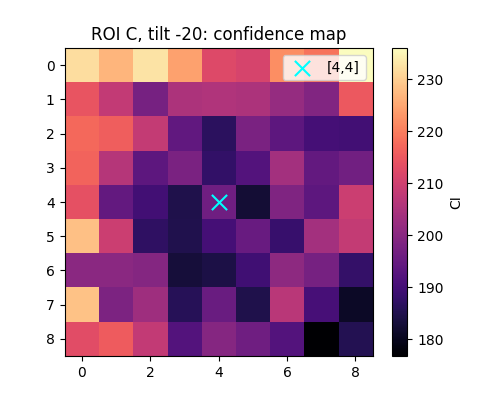

In [21]:
plt.figure(figsize=(5, 4))
plt.imshow(xmap.ci.reshape(xmap.shape), cmap="magma")
plt.colorbar(label="CI")
plt.scatter(4, 4, c="cyan", marker="x", s=120, label="[4,4]")
plt.legend()
plt.title("ROI C, tilt -20: confidence map")
plt.show()

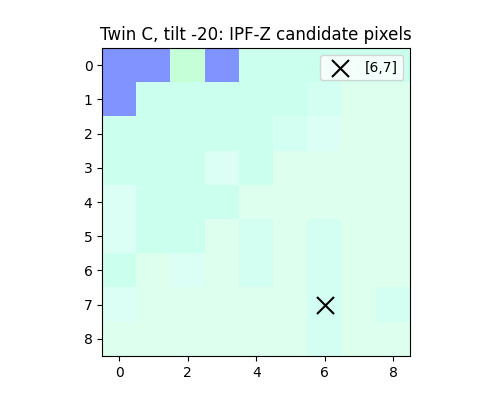

In [19]:
key_z = IPFColorKeyTSL(
    GaAs.point_group,
    Vector3d.zvector()
)

# RGB colors from orientations
rgb = key_z.orientation2color(xmap.orientations)

# reshape to image
rgb_map = rgb.reshape(xmap.shape + (3,))
#  mark candidate pixels on C -20 IPF-Z map
plt.figure(figsize=(5, 4))
plt.imshow(rgb_map)
#plt.scatter(4, 4, c="white", marker="x", s=150, label="[4,4]")
plt.scatter(6, 7, c="black", marker="x", s=150, label="[6,7]")
plt.legend()
plt.title("Twin C, tilt -20: IPF-Z candidate pixels")
plt.show()

Text(0.5, 0.98, 'ROI C, tilt -20: IPF-Z map')

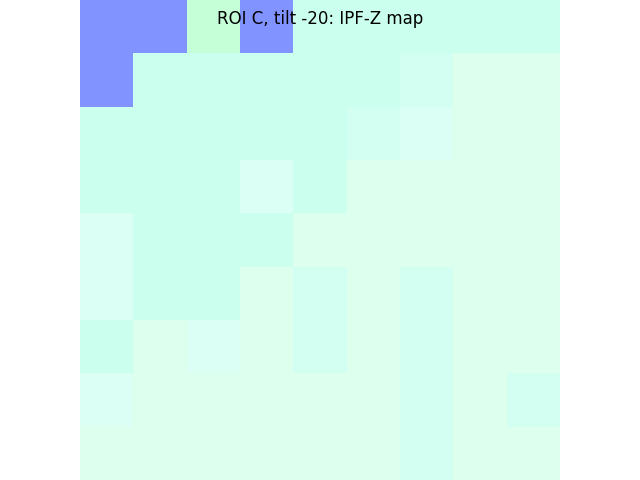

In [22]:
key_z = IPFColorKeyTSL(GaAs.point_group, Vector3d.zvector())

fig = xmap.plot(
    key_z.orientation2color(xmap.orientations),
    remove_padding=True,
    return_figure=True,
    scalebar=False
)

fig.suptitle("ROI C, tilt -20: IPF-Z map")

## 1. IPF-Z plots
sanity check for template matching plotting the highest scoring pixel.

direction = Vector3d.zvector(). which is the beam direction / zone axis direction

plot one twin across all tilts

In [ ]:
twin_key = "C"

tilt_keys = sorted(roi_results.keys())  # assumes roi_results[tilt]
n = len(tilt_keys)

fig = plt.figure(figsize=(2*n, 4))

for i, tilt in enumerate(tilt_keys):

    res = roi_results[tilt][twin_key]

    # ori shape: nav_x, nav_y, n_best

    oris = res.to_single_phase_orientations()[:, 0]
    ori = res.to_single_phase_orientations()[7, 0, 0]
    

    ax = fig.add_subplot(1, n, i + 1, projection="ipf", symmetry=GaAs.point_group)

    ax.scatter(
        ori,
        cmap="inferno",
    )

    ax.set_title(f"\nTilt {tilt} | Twin {twin_key}\n")

plt.tight_layout()
plt.show()

In [ ]:
# Plot one twin across all tilts
twin_key = "C"
tilt_keys = np.array(sorted(roi_results.keys()))

all_oris = []
all_tilts = []

for tilt in tilt_keys:
    res = roi_results[tilt][twin_key]
    ori = res.to_single_phase_orientations()[6, 7, 0]

    all_oris.append(ori)
    all_tilts.append(tilt)

oris_all = Orientation(
    np.stack([o.data.squeeze() for o in all_oris]),
    symmetry=GaAs.point_group
)

tilt_colors = np.array(all_tilts)

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tilt_keys.min(), vmax=tilt_keys.max())
rgba = cmap(norm(tilt_colors))

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="ipf", symmetry=GaAs.point_group)

ax.scatter(
    oris_all,
    color=rgba,
    alpha=0.9,
    s=80
)

ax.set_title(f"Twin {twin_key}\n")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.9)
cbar.set_label("Tilt")
cbar.set_ticks(tilt_keys)
cbar.set_ticklabels([str(t) for t in tilt_keys])

plt.tight_layout()
plt.show()

In [ ]:
# Plot one twin across all tilts
twin_key = "C"
tilt_keys = np.array(sorted(roi_results.keys()))

# data
all_oris = []
all_tilts = []

for tilt in tilt_keys:

    res = roi_results[tilt][twin_key]

    oris = res.to_single_phase_orientations()[0, 0, 0]

    all_oris.append(oris)

    n = oris.data.shape[0]
    all_tilts.append(np.full(n, tilt))

oris_all = Orientation(
    np.concatenate([o.data for o in all_oris]),
    symmetry=symmetry.Oh
)

tilt_colors = np.concatenate(all_tilts)

# colormap
cmap = plt.cm.plasma
norm = plt.Normalize(
    vmin=tilt_keys.min(),
    vmax=tilt_keys.max()
)

rgba = cmap(norm(tilt_colors))

# ---- plot ----
fig = plt.figure(figsize=(5, 4))

ax = fig.add_subplot(
    111,
    projection="ipf",
    symmetry=symmetry.Oh
)

ax.scatter(
    oris_all,
    color=rgba,
    alpha=0.9,
    s=80
)

ax.set_title(f"Twin {twin_key}")

# colorbar
sm = plt.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.8
)

cbar.set_label("Tilt")
cbar.set_ticks(tilt_keys)
cbar.set_ticklabels([str(t) for t in tilt_keys])

plt.tight_layout()
plt.show()

m-3m

# Choosing representative domain/pixel
Each roi can contain:
- more than one crystal orientation
- edge pixels from a neighbouring domain
- noisy or low-correlation pixels
- local overlap
- a region where template matching picks the wrong branch

the representative pixel should therefore:
1. It belongs to the correct domain
1. high template-matching quality
2. smooth orientation evolution through the tilt series
- whereas "quality" means: tilt-step continuity within the same ROI + orientation relashionship to neighbouring ROI

For each tilt:
    1. Get candidate-0 orientation map.
    2. Use the centre pixel as a first reference.
    3. Find pixels within e.g. 10° of the centre orientation.
    4. If too few pixels match, use the largest orientation-consistent cluster.
    5. Pick the medoid pixel of that region.
Across tilts:
    6. Use the median/most stable pixel coordinate as representative.
    7. Run Denis RANSAC candidate correction once.


2. Segment/cluster the IPF map into a few orientation regions.
3. Pick one medoid pixel from each region.
4. Run RANSAC only on those medoid pixels.
5. Choose the region whose RANSAC result gives the smoothest trajectory.

RANSAC was used after representative-domain selection. Since some ROIs contained more than one orientation region, the representative pixel could not always be chosen as the centre pixel or the highest-correlation pixel. The IPF orientation maps were therefore treated as domain maps: orientation-consistent regions were identified, and one medoid pixel from each region was tested using the RANSAC axis-angle trajectory method. The domain whose medoid produced the most continuous tilt-series trajectory was selected for the final analysis.

In [ ]:
import importlib
import pickle

import src.domain_selection as drs

importlib.reload(drs)

from src.domain_selection import (
    select_domains_fast_all_twins
)

1. To avoid relying on a manually selected representative pixel, the candidate-selection procedure was extended to the full ROI. For each pixel in an ROI, the n-best template-matching candidates were collected through the tilt series, and the smoothest candidate sequence was selected by minimizing symmetry-equivalent misorientation jumps between neighbouring tilts. The representative pixel was then chosen as the pixel whose optimized candidate sequence gave the most continuous trajectory. Low-correlation pixels were excluded before this search. This approach preserves the local diffraction information while avoiding averaging over mixed-domain ROIs.

fast

all pixels × candidate 0 only
then
top 5–8 pixels × all candidates

In [32]:
import importlib
import pickle

import src.axis_angle_roi as aar

importlib.reload(aar)

from src.axis_angle_roi import (
    run_fast_roi_trajectory_selection_all_twins, run_fast_roi_trajectory_selection_cached_all_twins
)

In [27]:
twin_keys = ["A", "B", "C", "D"]

axis_angle_results_roi_fast, representative_pixels_roi_fast, roi_fast_diagnostics = (
    run_fast_roi_trajectory_selection_all_twins(
        roi_results=roi_results,
        twin_keys=twin_keys,
        symmetry=GaAs.point_group,
        score_percentile=30,
        stride=2,
        keep_n=5,
        rank_weight=0.02,
    )
)


=== Twin A: fast ROI trajectory selection ===
Shortlisted pixels: 5
pixel=(0, 2), score=11.38, max jump=18.80°, chosen=[2 6 0 4 1 4 0]
pixel=(8, 4), score=11.31, max jump=18.70°, chosen=[6 0 0 4 5 6 0]
pixel=(0, 0), score=10.91, max jump=18.70°, chosen=[2 2 0 6 4 6 0]
pixel=(0, 6), score=26.15, max jump=35.43°, chosen=[6 0 0 6 6 4 4]
pixel=(2, 8), score=33.41, max jump=50.21°, chosen=[4 0 0 5 6 0 2]

Selected Twin A pixel: (0, 0)
Selected jumps: [ 4.86  4.93 18.7   7.36  7.98  2.15]

=== Twin B: fast ROI trajectory selection ===


ValueError: all input arrays must have the same shape

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results=axis_angle_results_roi_fast,
    twin_keys=twin_keys,
    symmetry=GaAs.point_group,
)

cached

In [33]:
axis_angle_results_roi_fast, representative_pixels_roi_fast, roi_fast_diagnostics = (
    run_fast_roi_trajectory_selection_cached_all_twins(
        roi_results=roi_results,
        twin_keys=twin_keys,
        symmetry=GaAs.point_group,
        score_percentile=30,
        stride=2,
        keep_n=5,
        rank_weight=0.02,
    )
)


=== Twin A: cached ROI trajectory selection ===
Screened pixels: 16
Shortlisted pixels: 5
pixel=(0, 2), score=11.38, max jump=18.80°, chosen=[2 6 0 4 1 4 0]
pixel=(8, 4), score=11.31, max jump=18.70°, chosen=[6 0 0 4 5 6 0]
pixel=(0, 0), score=10.91, max jump=18.70°, chosen=[2 2 0 6 4 6 0]
pixel=(0, 6), score=26.15, max jump=35.43°, chosen=[6 0 0 6 6 4 4]
pixel=(2, 8), score=33.41, max jump=50.21°, chosen=[4 0 0 5 6 0 2]

Selected Twin A pixel: (0, 0)
Selected jumps: [ 4.86  4.93 18.7   7.36  7.98  2.15]

=== Twin B: cached ROI trajectory selection ===
Screened pixels: 18
Shortlisted pixels: 5
pixel=(0, 4), score=3.05, max jump=5.58°, chosen=[0 2 0 6 1 0 0]
pixel=(0, 2), score=3.08, max jump=5.58°, chosen=[4 2 0 6 0 7 0]
pixel=(6, 6), score=3.06, max jump=5.59°, chosen=[0 0 0 6 4 0 0]
pixel=(6, 2), score=2.79, max jump=5.54°, chosen=[7 2 0 2 4 0 0]
pixel=(2, 6), score=3.02, max jump=5.53°, chosen=[0 2 0 0 2 6 0]

Selected Twin B pixel: (6, 2)
Selected jumps: [5.54 5.   5.03 5.04 5.14 

In [34]:
# -------------------------
# Save cached ROI trajectory selection results
# -------------------------

with open(results_path / "axis_angle_selected_orientations_roi_fast.pkl", "wb") as f:
    pickle.dump(axis_angle_results_roi_fast, f)

with open(results_path / "representative_pixels_roi_fast.pkl", "wb") as f:
    pickle.dump(representative_pixels_roi_fast, f)

with open(results_path / "roi_fast_selection_diagnostics.pkl", "wb") as f:
    pickle.dump(roi_fast_diagnostics, f)

print("Saved cached ROI trajectory selection results.")

Saved cached ROI trajectory selection results.


In [35]:
# -------------------------
# Save representative pixels as JSON
# -------------------------

representative_pixels_json = {
    key: [int(px), int(py)]
    for key, (px, py) in representative_pixels_roi_fast.items()
}

with open(results_path / "representative_pixels_roi_fast.json", "w") as f:
    json.dump(representative_pixels_json, f, indent=4)

print("Saved representative pixels JSON.")

Saved representative pixels JSON.


old

In [ ]:
twin_keys = ["A", "B", "C", "D"]

clustering_tilts = {
    "A": 0,
    "B": -10,
    "C": -5,
    "D": -5,
}

axis_angle_results_domain_fast, representative_pixels_domain_fast, domain_selection_fast = (
    select_domains_fast_all_twins(
        roi_results=roi_results,
        twin_keys=twin_keys,
        symmetry=GaAs.point_group,
        clustering_tilts=clustering_tilts,
        score_percentile=40,
        eps=0.05,
        min_samples=3,
        min_domain_size=3,
        max_domains=3,
        selection_n_iter=500,
        final_n_iter=4000,
        threshold=0.10,
        min_inliers=3,
        max_acceptable_jump=20,
    )
)

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results=axis_angle_results_domain_fast,
    twin_keys=twin_keys,
    symmetry=GaAs.point_group,
)

In [ ]:
for twin_key in twin_keys:

    fig = plot_domain_selection_qc(
        domain_selection=domain_selection,
        twin_key=twin_key,
        title=f"Twin {twin_key}: selected orientation domain",
    )

    fig.savefig(
        figures_path / f"domain_ransac_selection_twin_{twin_key}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [ ]:
representative_pixels = {
    "A": (4, 4),
    "B": (4, 4),
    "C": (4, 4),
    "D": (4, 4),
}

In [ ]:
twin_keys = ["A", "B", "C", "D"]

representative_pixels_auto, pixel_diagnostics = (
    choose_representative_pixels_all_twins(
        roi_results=roi_results,
        twin_keys=twin_keys,
        symmetry=GaAs.point_group,
        max_orientation_distance=10,
        min_score_percentile=90,
    )
)

In [ ]:
axis_angle_results_auto_ransac = run_denis_selection_all_twins(
    roi_results=roi_results,
    twin_keys=twin_keys,
    representative_pixels=representative_pixels_auto,
    symmetry=GaAs.point_group,
    n_iter=4000,
    threshold=0.10,
    min_inliers=3,
)

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results=axis_angle_results_auto_ransac,
    twin_keys=twin_keys,
    symmetry=GaAs.point_group,
)

# Extract best candidates with axis-angle

##
Template matching occasionally produces symmetry-equivalent orientation branches.
Axis-angle continuity was therefore explored as a method for identifying branch jumps.
However, crystallographic consistency in IPF-Z space and stereographic trajectories was used as the final selection criterion.


For each twin:
3. start with candidate 0 for the representative pixel
4. fit a smooth tilt trajectory (PCA line) in axis-angle space
5. find tilts where candidate 0 is off the trajectory
6. replace only those bad tilts with a better candidate
7. store the corrected orientation sequence

using axis-angle space, where any crystal orientation can be represented as `rotation axis + rotation angle`, for example 60° around [111]. This then becomes a vector: `rotation_vector = axis * angle`.
The tilt series represent "smooth" orientation changes -> smooth curve in 3D axis-angle space. One could represent the crystal orientations in Euler angles, IPF positions and stereographic coordinates, but points in a 3D mathematical orientaion space, as axis-angle space is, can better show tilt orientations in a line.




In [ ]:
axis_angle_results = run_axis_angle_selection(
    roi_results,
    twin_keys=["A", "B", "C", "D"],
    symmetry=GaAs.point_group,
    threshold_percentile=70,
)

In [ ]:
for twin_key in ["A", "B", "C", "D"]:

    r = axis_angle_results[twin_key]

    tilt_keys = r["tilts"]
    center_oris = r["center_oris"]
    axis_oris = r["axis_oris"]

    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=tilt_keys.min(), vmax=tilt_keys.max())
    rgba = cmap(norm(tilt_keys))

    fig = plt.figure(figsize=(10, 4))

    ax1 = fig.add_subplot(121, projection="ipf", symmetry=symmetry.Oh)
    ax1.scatter(center_oris, color=rgba, s=90, alpha=0.9)
    ax1.set_title(f"Twin {twin_key}: candidate 0 \n")

    ax2 = fig.add_subplot(122, projection="ipf", symmetry=symmetry.Oh)
    ax2.scatter(axis_oris, color=rgba, s=90, alpha=0.9)
    ax2.set_title(f"Twin {twin_key}: axis-angle selected \n")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.85)
    cbar.set_label("Tilt")
    cbar.set_ticks(tilt_keys)

    plt.show()

In [ ]:
twin_keys = ["A", "B", "C", "D"]

axis_angle_results = run_axis_angle_selection_all_twins(
    roi_results=roi_results,
    twin_keys=twin_keys,
    representative_pixels=representative_pixels,
    symmetry=GaAs.point_group,
    threshold_percentile=70,
)

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results=axis_angle_results,
    twin_keys=["A", "B", "C", "D"],
    symmetry=GaAs.point_group,
)

## save axis-angle orientations

In [ ]:
with open(results_path / "axis_angle_selected_orientations.pkl", "wb") as f:
    pickle.dump(axis_angle_results, f)

print("Axis-angle selected orientations saved.")

# Alternative candidate selection using Denis-style axis-angle trajectory fitting

Template matching returns several candidate orientations for each ROI and tilt. The current candidate-selection workflow uses axis-angle continuity as a diagnostic for branch jumps. However, Twin C showed remaining discontinuities between neighbouring tilt steps, suggesting that the selected candidate sequence may still switch between equivalent or physically inconsistent branches.

As an alternative, a Denis-style axis-angle trajectory method was tested. In this method, the candidate orientations are represented in axis-angle space, where a smooth tilt series should form an approximately continuous trajectory. A robust line is fitted to the candidate trajectory, outlying tilt steps are identified, and the outlying orientations are replaced by the available template-matching candidate closest to the fitted trajectory. The corrected sequence is then validated by checking the neighbour-to-neighbour misorientation between tilt steps and by plotting the resulting IPF and stereographic trajectories.

Extracting best candidate inspired by: https://github.com/denislobe/Masteroppgave/blob/main/Code/aluminium_new.ipynb

This method is used only as a candidate-selection refinement. The final crystallographic interpretation is still based on reconstructed zone-axis vectors, stereographic trajectories, fitted great-circle arc poles, and angular relationships between the fitted arcs.

candidate 0 through tilt series
- use RANSAC to find the smooth inlier trajectory
- ignore points that do not belong to that trajectory
- estimate where outlier tilts should lie along the line
- choose the candidate closest to that expected position

In [ ]:
representative_pixels = {
    "A": (4, 4),
    "B": (4, 4),
    "C": (6, 7),
    "D": (2, 3),
}

Test for twin C

In [ ]:
twin_key = "C"
px, py = representative_pixels[twin_key]

result_C_denis = run_denis_selection(
    roi_results=roi_results,
    twin_key=twin_key,
    px=px,
    py=py,
    symmetry=GaAs.point_group,
    n_iter=4000,
    threshold=0.10,
    min_inliers=3,
)

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results={"C": result_C_denis},
    twin_keys=["C"],
    symmetry=GaAs.point_group,
)

all twins denis ransac method

In [ ]:
# -------------------------
# Run Denis RANSAC axis-angle selection for all twins
# -------------------------

twin_keys = ["A", "B", "C", "D"]

axis_angle_results_denis = run_denis_selection_all_twins(
    roi_results=roi_results,
    twin_keys=twin_keys,
    representative_pixels=representative_pixels,
    symmetry=GaAs.point_group,
    n_iter=4000,
    threshold=0.10,
    min_inliers=3,
)

In [ ]:
print_tilt_step_misorientation(
    axis_angle_results=axis_angle_results_denis,
    twin_keys=["A", "B", "C", "D"],
    symmetry=GaAs.point_group,
)

In [ ]:
with open(results_path / "axis_angle_selected_orientations_denis_ransac.pkl", "wb") as f:
    pickle.dump(axis_angle_results_denis, f)

print("Saved Denis-style RANSAC axis-angle selected orientations.")

# IPF plots

In [ ]:
# Plot axis-angle selected orientations
# one row per twin, one IPF panel per tilt

twin_keys = ["A", "B", "C", "D"]

for twin_key in twin_keys:

    r = axis_angle_results[twin_key]

    tilt_keys = r["tilts"]
    axis_oris = r["axis_oris"]
    chosen_idx = r["chosen_idx"]

    n = len(tilt_keys)

    #cmap = plt.cm.plasma
    norm = plt.Normalize(
        vmin=tilt_keys.min(),
        vmax=tilt_keys.max()
    )

    fig = plt.figure(figsize=(2*n, 4))

    for i, tilt in enumerate(tilt_keys):

        ori = axis_oris[i]

        #rgba = cmap(norm(tilt))

        ax = fig.add_subplot(
            1,
            n,
            i + 1,
            projection="ipf",
            symmetry=GaAs.point_group
        )

        ax.scatter(
            ori,
            s=100
        )

        ax.set_title(
            f"Tilt {tilt} \n",
            fontsize = 14
        )

    fig.suptitle(
        f"Twin {twin_key}: axis-angle selected orientations \n",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

test

In [ ]:
twin_key = "D"

r = axis_angle_results[twin_key]
px, py = r["center_pixel"]

for test_tilt in [-5, 0]:

    print(f"\nTwin {twin_key}, tilt {test_tilt}")

    res = roi_results[test_tilt][twin_key]
    ori_full = res.to_single_phase_orientations()

    for idx in range(8):

        ori = ori_full[px, py, idx]

        v = ori * Vector3d.zvector()

        print(f"candidate {idx}: vector = {v.data.squeeze()}")

In [ ]:
for idx_m5 in range(8):
    for idx_0 in range(8):

        ori_m5 = roi_results[-5]["D"].to_single_phase_orientations()[px, py, idx_m5]
        ori_0  = roi_results[0]["D"].to_single_phase_orientations()[px, py, idx_0]

        v_m5 = ori_m5 * Vector3d.zvector()
        v_0  = ori_0  * Vector3d.zvector()

        ang = float(v_m5.angle_with(v_0, degrees=True))

        if ang < 10:
            print(
                f"-5 cand {idx_m5} → 0 cand {idx_0}: "
                f"{ang:.2f}°"
            )

## xmaps